# Model Exploration

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score
from sklearn.neural_network import MLPClassifier

In [2]:
train = pd.read_csv('data/train_processed.csv')

In [3]:
train.columns

Index(['Id', 'Slope', 'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4',
       'Soil_Type5', 'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9',
       'Soil_Type10', 'Soil_Type11', 'Soil_Type12', 'Soil_Type13',
       'Soil_Type14', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18',
       'Soil_Type19', 'Soil_Type20', 'Soil_Type21', 'Soil_Type22',
       'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26',
       'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30',
       'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34',
       'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38',
       'Soil_Type39', 'Soil_Type40', 'Cover_Type', 'Distance_To_Hydrology',
       'Log_Horiz_Hydrology', 'Log_Horiz_Roadways', 'Log_Horiz_Fire',
       'Aspect_sin', 'Aspect_cos', 'Hillshade_Mean',
       'Elevation_Wilderness_Area1', 'Elevation_Wilderness_Area2',
       'Elevation_Wilderness_Area3', 'Elevation_Wilderness_Area4',
       'Close_To_Water', 'High_Altitude'],


In [4]:
X = train.drop(columns=["Cover_Type", "Id"])
y = train["Cover_Type"]
y_shifted = y - 1

## Simple default models

In [5]:
basic_models = {
    "LogReg": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]),
    "LDA": Pipeline([("scaler", StandardScaler()), ("model", LinearDiscriminantAnalysis())]),
    "QDA": Pipeline([("scaler", StandardScaler()), ("model", QuadraticDiscriminantAnalysis())]),
    "Naive Bayes": GaussianNB(),
    "KNN": Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier())]),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Linear SVM": Pipeline([("scaler", StandardScaler()), ("model", LinearSVC(dual=False, random_state=42))]),
    "Kernel SVM (RBF)": Pipeline([("scaler", StandardScaler()), ("model", SVC(kernel="rbf", random_state=42))]),
    "Bagging (Trees)": BaggingClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(random_state=42, n_jobs=-1),
    "MLP": Pipeline([("scaler", StandardScaler()),("model", MLPClassifier(max_iter=1000, random_state=42))]), #  Increased max_iter to 1000 for convergence
    "DNN": Pipeline([("scaler", StandardScaler()), ("model", MLPClassifier(hidden_layer_sizes=(100, 100, 100), max_iter=1000, random_state=42))]) #  Increased max_iter to 1000 for convergence
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
basic_results = []

for name, model in basic_models.items():
    print(f"Model: {name}")

    if any(x in name for x in ["XGB", "LightGBM"]):
        y_true = y_shifted
    else:
        y_true = y

    cv_results = cross_validate(model, X, y_true, cv=skf, scoring="accuracy", n_jobs=-1)
    
    basic_results.append({
        "Model": name,
        "Mean Accuracy": cv_results["test_score"].mean(),
        "Std Dev": cv_results["test_score"].std()
    })

Model: LogReg
Model: LDA
Model: QDA
Model: Naive Bayes


/Users/benedikt/anaconda3/lib/python3.11/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Users/benedikt/anaconda3/lib/python3.11/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Users/benedikt/anaconda3/lib/python3.11/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Users/benedikt/anaconda3/lib/python3.11/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help 

Model: KNN
Model: Decision Tree
Model: Linear SVM
Model: Kernel SVM (RBF)
Model: Bagging (Trees)
Model: Random Forest
Model: AdaBoost
Model: Gradient Boosting
Model: XGBoost
Model: LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001451 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001427 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2717
[LightGBM] [Info] Total Bins 2711
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001299 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the ov

In [6]:
basic_results_df = pd.DataFrame(basic_results)
print(basic_results_df.sort_values(["Mean Accuracy"], ascending=False))

                Model  Mean Accuracy   Std Dev
9       Random Forest       0.860119  0.008199
13           LightGBM       0.859061  0.008803
12            XGBoost       0.858730  0.008050
8     Bagging (Trees)       0.845172  0.007261
15                DNN       0.823214  0.004632
14                MLP       0.815079  0.011062
11  Gradient Boosting       0.801389  0.010408
5       Decision Tree       0.794643  0.009360
4                 KNN       0.773413  0.003842
7    Kernel SVM (RBF)       0.713426  0.006916
0              LogReg       0.690873  0.006515
6          Linear SVM       0.674735  0.005806
1                 LDA       0.645238  0.007010
3         Naive Bayes       0.513624  0.006300
10           AdaBoost       0.467593  0.036825
2                 QDA       0.447751  0.015000


## Basic models with different scoring

In [7]:
scoring_metrics = {
    'accuracy': 'accuracy',
    'balanced_acc': 'balanced_accuracy',
    'f1_macro': 'f1_macro',
    'precision': 'precision_macro',
    'recall': 'recall_macro'
}

different_metrics_results = []

for name, model in basic_models.items():
    print(f"Model: {name}")

    if any(x in name for x in ["XGB", "LightGBM"]):
        y_true = y_shifted
    else:
        y_true = y

    cv_results = cross_validate(model, X, y_true, cv=skf, scoring=scoring_metrics, n_jobs=-1)
    
    different_metrics_results.append({
            "Model": name,
            "Accuracy": cv_results["test_accuracy"].mean(),
            "Balanced Acc": cv_results["test_balanced_acc"].mean(),
            "F1 Macro": cv_results["test_f1_macro"].mean(),
            "Precision": cv_results["test_precision"].mean(),
            "Recall": cv_results["test_recall"].mean()
    })

Model: LogReg
Model: LDA
Model: QDA


/Users/benedikt/anaconda3/lib/python3.11/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Users/benedikt/anaconda3/lib/python3.11/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Users/benedikt/anaconda3/lib/python3.11/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Users/benedikt/anaconda3/lib/python3.11/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help 

Model: Naive Bayes
Model: KNN
Model: Decision Tree
Model: Linear SVM
Model: Kernel SVM (RBF)
Model: Bagging (Trees)
Model: Random Forest
Model: AdaBoost


/Users/benedikt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/benedikt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Model: Gradient Boosting
Model: XGBoost
Model: LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003280 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003341 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2718
[LightGBM] [Info] Total Bins 2711
[LightGBM] [Info] Number of data points in the train set: 12096, number of used features: 44
[LightGBM] [Info] Number of data points in the train set: 12096, number of used features: 44
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of te

In [8]:
different_metrics_results_df = pd.DataFrame(different_metrics_results)
print(different_metrics_results_df.sort_values(["Accuracy"], ascending=False))

                Model  Accuracy  Balanced Acc  F1 Macro  Precision    Recall
9       Random Forest  0.860119      0.860119  0.857869   0.857539  0.860119
13           LightGBM  0.859061      0.859061  0.856824   0.856493  0.859061
12            XGBoost  0.858730      0.858730  0.856665   0.856218  0.858730
8     Bagging (Trees)  0.845172      0.845172  0.843297   0.843222  0.845172
15                DNN  0.823214      0.823214  0.821406   0.823188  0.823214
14                MLP  0.815079      0.815079  0.813842   0.814002  0.815079
11  Gradient Boosting  0.801389      0.801389  0.797464   0.797656  0.801389
5       Decision Tree  0.794643      0.794643  0.793882   0.793719  0.794643
4                 KNN  0.773413      0.773413  0.768746   0.768022  0.773413
7    Kernel SVM (RBF)  0.713426      0.713426  0.709666   0.709958  0.713426
0              LogReg  0.690873      0.690873  0.687621   0.686410  0.690873
6          Linear SVM  0.674735      0.674735  0.669271   0.668658  0.674735

## Confusion Matrix for RF, LightGBM, XGBoost

In [9]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

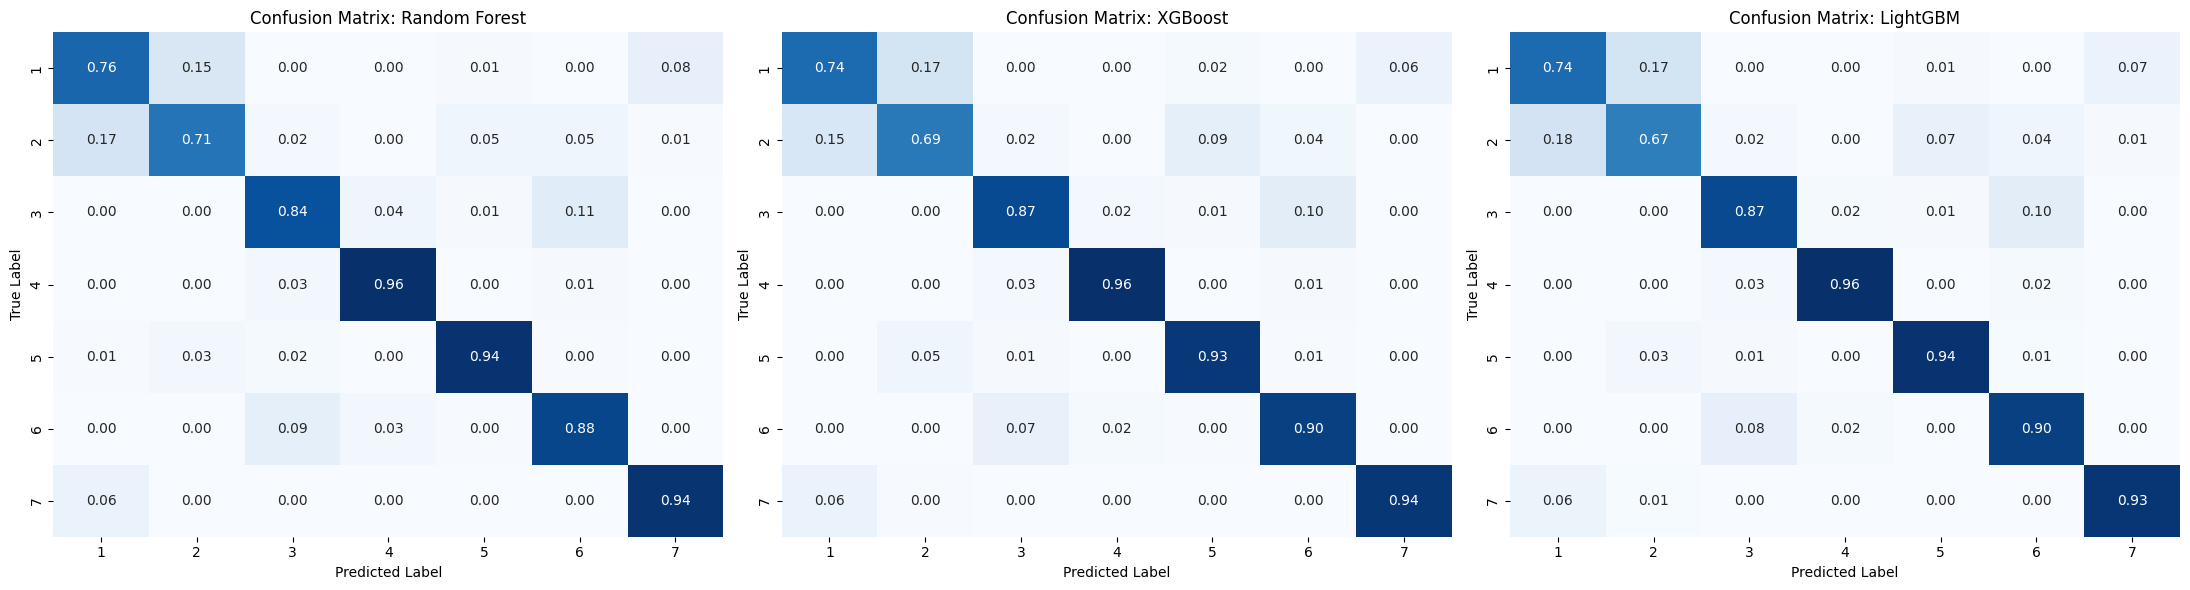

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
y_val_shifted = y_test - 1

best_rf = RandomForestClassifier(random_state=42, n_jobs=-1).fit(X_train, y_train)
best_xgb = XGBClassifier(random_state=42, n_jobs=-1).fit(X_train, y_train - 1)
best_lgbm = LGBMClassifier(random_state=42, n_jobs=-1, verbosity=-1).fit(X_train, y_train - 1)

models = {
    "Random Forest": (best_rf, y_test),
    "XGBoost": (best_xgb, y_val_shifted),
    "LightGBM": (best_lgbm, y_val_shifted)
}

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for i, (name, (model, y_true)) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f"Confusion Matrix: {name}")
    axes[i].set_xlabel("Predicted Label")
    axes[i].set_ylabel("True Label")
    if name == "Random Forest":
        labels = [1, 2, 3, 4, 5, 6, 7]
    else:
        [0, 1, 2, 3, 4, 5, 6]
    axes[i].set_xticklabels(labels)
    axes[i].set_yticklabels(labels)

plt.tight_layout()
plt.show()

## Auto ML

In [15]:
from flaml import AutoML

In [18]:
automl = AutoML()

automl.fit(
    X_train=X,
    y_train=y-1,
    time_budget= 600,  
    metric= "accuracy",
    task= "classification",
    seed= 42,
)

print(f"Best ML learner: {automl.best_estimator}")
print(f"Best hyperparameter config: {automl.best_config}")
print(f"Best accuracy on validation data: {1 - automl.best_loss}")

[flaml.automl.logger: 02-21 16:47:49] {2375} INFO - task = classification
[flaml.automl.logger: 02-21 16:47:49] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 02-21 16:47:49] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 02-21 16:47:49] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'lrl1']
[flaml.automl.logger: 02-21 16:47:49] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 02-21 16:47:49] {3046} INFO - Estimated sufficient time budget=2056s. Estimated necessary time budget=48s.
[flaml.automl.logger: 02-21 16:47:49] {3097} INFO -  at 0.3s,	estimator lgbm's best error=3.7586e-01,	best estimator lgbm's best error=3.7586e-01
[flaml.automl.logger: 02-21 16:47:49] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 02-21 16:47:50] {3097} INFO -  at 0.5s,	estimator lgbm's best error=3.7573e-01,	best estimator lgbm's best error=3.7573e-01
[flaml.auto

In [19]:
test_df = pd.read_csv("data/test_processed.csv")
preds_0_indexed = automl.predict(test_df)
final_preds = preds_0_indexed + 1

submission = pd.DataFrame({
    "Id": test_df["Id"],
    "Cover_Type": final_preds
})

submission.to_csv("automl_600_submission.csv", index=False)

## Hyperparamter tuning

### Optuna RF

In [6]:
import optuna

In [15]:
def objective(trial):

    param = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 10, 50),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_float("max_features", 0.1, 1.0),
        "bootstrap": True,
        "criterion": "gini",
        "random_state": 42,
        "n_jobs": 1,
    }

    model = RandomForestClassifier(**param)
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    cv_results = cross_validate(model, X, y, cv=skf, scoring="accuracy", n_jobs=-1)

    return cv_results["test_score"].mean()


study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(objective, n_trials=100)

[I 2026-02-22 16:21:17,336] A new study created in memory with name: no-name-17efd3a2-3214-4406-9646-b3eb69f3ce08
[I 2026-02-22 16:21:35,496] Trial 0 finished with value: 0.8381613756613756 and parameters: {'n_estimators': 300, 'max_depth': 18, 'min_samples_split': 8, 'min_samples_leaf': 6, 'max_features': 0.3813871453106731}. Best is trial 0 with value: 0.8381613756613756.
[I 2026-02-22 16:21:43,998] Trial 1 finished with value: 0.8296957671957671 and parameters: {'n_estimators': 173, 'max_depth': 21, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': 0.4251796769892608}. Best is trial 0 with value: 0.8381613756613756.
[I 2026-02-22 16:21:59,923] Trial 2 finished with value: 0.8415343915343915 and parameters: {'n_estimators': 328, 'max_depth': 36, 'min_samples_split': 13, 'min_samples_leaf': 5, 'max_features': 0.8769399367701196}. Best is trial 2 with value: 0.8415343915343915.
[I 2026-02-22 16:22:27,981] Trial 3 finished with value: 0.8326058201058201 and parameters: {'n

In [25]:
rf_best_params = study_rf.best_params
optuna_rf_model = RandomForestClassifier(**rf_best_params, n_jobs=-1, random_state=42)
optuna_rf_model.fit(X, y)

trained_features = X.columns.tolist()
X_test_filtered = test_df[trained_features]

test_preds = optuna_rf_model.predict(X_test_filtered)

submission = pd.DataFrame({
    "Id": test_df["Id"],
    "Cover_Type": test_preds
})

submission.to_csv("optuna_rf_submission.csv", index=False)

### Optuna LightGBM

In [9]:
def objective(trial):
    param = {
        "objective": "multiclass",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "random_state": 42,
        "n_jobs": 1,
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 255),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    model = LGBMClassifier(**param)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_results = cross_validate(model, X, y_shifted, cv=skf, scoring="accuracy", n_jobs=-1)
    return cv_results["test_score"].mean()

study_lgbm = optuna.create_study(direction="maximize")
study_lgbm.optimize(objective, n_trials=100)

[I 2026-02-22 14:04:09,095] A new study created in memory with name: no-name-5a0f16de-0846-4e95-b222-ca39bb39bb4d
[I 2026-02-22 14:04:32,095] Trial 0 finished with value: 0.8744047619047619 and parameters: {'n_estimators': 878, 'learning_rate': 0.07729083801456628, 'num_leaves': 177, 'min_child_samples': 89, 'reg_lambda': 0.17337049296672224}. Best is trial 0 with value: 0.8744047619047619.
[I 2026-02-22 14:04:35,763] Trial 1 finished with value: 0.8761243386243386 and parameters: {'n_estimators': 146, 'learning_rate': 0.26293755471900804, 'num_leaves': 213, 'min_child_samples': 89, 'reg_lambda': 1.0675204587157327e-05}. Best is trial 1 with value: 0.8761243386243386.
[I 2026-02-22 14:04:53,730] Trial 2 finished with value: 0.875 and parameters: {'n_estimators': 938, 'learning_rate': 0.053539651406061047, 'num_leaves': 48, 'min_child_samples': 100, 'reg_lambda': 6.280595306610247e-05}. Best is trial 1 with value: 0.8761243386243386.
[I 2026-02-22 14:05:12,227] Trial 3 finished with val

In [28]:
lgbm_best_params = study_lgbm.best_params
optuna_lgbm_model = LGBMClassifier(**lgbm_best_params, n_jobs=-1, random_state=42)
optuna_lgbm_model.fit(X, y)

test_preds_lgbm = optuna_lgbm_model.predict(X_test_filtered)

submission = pd.DataFrame({
    "Id": test_df["Id"],
    "Cover_Type": test_preds_lgbm
})

submission.to_csv("optuna_lgbm_submission.csv", index=False)

### Optuna XGBoost

In [7]:
def objective(trial):
    param = {
        "objective": "multi:softprob",
        "random_state": 42,
        "n_jobs": 1,
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_child_weight": trial.suggest_float("min_child_weight", 0.1, 20.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }
    model = XGBClassifier(**param)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    cv_results = cross_validate(model, X, y_shifted, cv=skf, scoring="accuracy", n_jobs=-1)
    
    return cv_results["test_score"].mean()

study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective, n_trials=50)

[I 2026-02-22 13:10:59,086] A new study created in memory with name: no-name-e8982ed4-812f-4172-aa7d-bf3d1baf0189
[I 2026-02-22 13:11:23,337] Trial 0 finished with value: 0.864616402116402 and parameters: {'n_estimators': 937, 'learning_rate': 0.011717565706121633, 'max_depth': 19, 'min_child_weight': 7.524978915975864, 'reg_lambda': 1.1159882034532264e-06}. Best is trial 0 with value: 0.864616402116402.
[I 2026-02-22 13:11:26,404] Trial 1 finished with value: 0.7996693121693121 and parameters: {'n_estimators': 279, 'learning_rate': 0.09237050772332919, 'max_depth': 3, 'min_child_weight': 14.826369336076393, 'reg_lambda': 7.092467826196105e-07}. Best is trial 0 with value: 0.864616402116402.
[I 2026-02-22 13:11:35,676] Trial 2 finished with value: 0.8683862433862434 and parameters: {'n_estimators': 548, 'learning_rate': 0.19013965619015685, 'max_depth': 15, 'min_child_weight': 9.73516863855039, 'reg_lambda': 0.0005565469623166024}. Best is trial 2 with value: 0.8683862433862434.
[I 202

In [8]:
test_df = pd.read_csv("data/test_processed.csv")

xgb_best_params = study_xgb.best_params
optuna_xgb_model = XGBClassifier(**xgb_best_params, n_jobs=-1, random_state=42)
optuna_xgb_model.fit(X, y_shifted)

trained_features = X.columns.tolist()
X_test_filtered = test_df[trained_features]

test_preds_shifted = optuna_xgb_model.predict(X_test_filtered)
final_preds = test_preds_shifted + 1

submission = pd.DataFrame({
    "Id": test_df["Id"],
    "Cover_Type": final_preds
})

submission.to_csv("optuna_xgb_submission.csv", index=False)


## Mislabelling of 1/2 and 3/6 challenge

In [10]:
custom_weights = {
    0: 1.5,  # Type 1 high confusion with 2
    1: 1.5,  # Type 2 high confusion with 1
    2: 1.2,  # Type 3 confusion with 6
    3: 1.0,  
    4: 1.0,
    5: 1.2,  # Type 6 confusion with 3
    6: 1.0
}

lgbm_optuna_params = study_lgbm.best_params

weighted_lgbm = LGBMClassifier(
    **lgbm_optuna_params,
    class_weight=custom_weights,
    random_state=42,
    n_jobs=-1
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results_weighted = cross_validate(
    weighted_lgbm, X, y_shifted, 
    cv=skf, 
    scoring="accuracy", 
    return_estimator=True,
    n_jobs=-1
)

print(f"Weighted Mean Accuracy: {cv_results_weighted['test_score'].mean():.4f}")
print(f"Unweighted Best Accuracy (Optuna): {study_lgbm.best_value:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001110 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001121 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001056 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001155 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2718
[LightGBM] [Info] Total Bins 2711
[LightGBM] [Info] Total Bins

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000608 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2718
[LightGBM] [Info] Number of data points in the train set: 12096, number of used features: 44
[LightGBM] [Info] Start training from score -1.722767
[LightGBM] [Info] Start training from score -1.722767
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -2.128232
[LightGBM] [Info] Start training from score -2.128232
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -2.128232
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

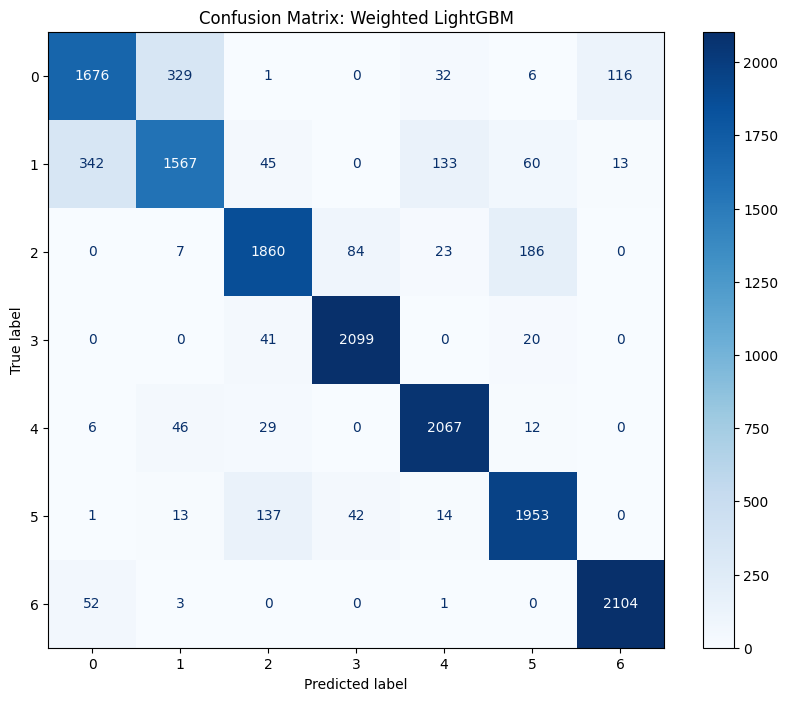

In [11]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay
first_model = cv_results_weighted["estimator"][0]
y_pred_weighted = cross_val_predict(weighted_lgbm, X, y_shifted, cv=skf)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_shifted, y_pred_weighted, ax=ax, cmap="Blues")
plt.title("Confusion Matrix: Weighted LightGBM")
plt.show()

In [12]:
weight_options = [1.5, 2.0, 2.5, 3.0]
results = {}

for w in weight_options:
    test_weights = {0: w, 1: w, 2: 1.2, 3: 1.0, 4: 1.0, 5: 1.2, 6: 1.0}
    
    model = LGBMClassifier(**study_lgbm.best_params, class_weight=test_weights, n_jobs=-1)
    cv_res = cross_validate(model, X, y_shifted, cv=skf, scoring="accuracy")
    
    mean_acc = cv_res["test_score"].mean()
    results[w] = mean_acc
    print(f"Weight {w}: Accuracy {mean_acc:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000406 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2718
[LightGBM] [Info] Number of data points in the train set: 12096, number of used features: 44
[LightGBM] [Info] Start training from score -1.722767
[LightGBM] [Info] Start training from score -1.722767
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -2.128232
[LightGBM] [Info] Start training from score -2.128232
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -2.128232
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

In [13]:
fine_tune_weights = [1.1, 1.2, 1.25, 1.35, 1.5]
fine_results = {}

for w in fine_tune_weights:
    test_weights = {0: w, 1: w, 2: 1.2, 3: 1.0, 4: 1.0, 5: 1.2, 6: 1.0}
    
    model = LGBMClassifier(**study_lgbm.best_params, class_weight=test_weights, n_jobs=-1, verbosity=-1)
    cv_res = cross_validate(model, X, y_shifted, cv=skf, scoring="accuracy")
    
    mean_acc = cv_res["test_score"].mean()
    fine_results[w] = mean_acc
    print(f"Weight {w}: Accuracy {mean_acc:.4f}")

Weight 1.1: Accuracy 0.8785
Weight 1.2: Accuracy 0.8796
Weight 1.25: Accuracy 0.8791
Weight 1.35: Accuracy 0.8790
Weight 1.5: Accuracy 0.8813


In [14]:
weighted_lgbm.fit(X, y_shifted)
preds_0_indexed = weighted_lgbm.predict(X_test_filtered)
final_preds = preds_0_indexed + 1

submission = pd.DataFrame({
    "Id": test_df["Id"],
    "Cover_Type": final_preds
})

submission.to_csv("submission_weighted_lgbm_1.5.csv", index=False)

## Stacking

In [16]:
from sklearn.ensemble import StackingClassifier

base_models = [
    ("rf", RandomForestClassifier(**study_rf.best_params, n_jobs=1, random_state=42)),
    ("lgbm", LGBMClassifier(**study_lgbm.best_params, n_jobs=1, random_state=42)),
    ("xgb", XGBClassifier(**study_xgb.best_params, n_jobs=1, random_state=42))
]

meta_learner = LogisticRegression(max_iter=1000)

stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=5,
    n_jobs=-1,
    passthrough=False
)

stack_model.fit(X, y_shifted)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000597 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2754
[LightGBM] [Info] Number of data points in the train set: 15120, number of used features: 45
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

,estimators,"[('rf', ...), ('lgbm', ...), ...]"
,final_estimator,LogisticRegre...max_iter=1000)
,cv,5
,stack_method,'auto'
,n_jobs,-1
,passthrough,False
,verbose,0
,n_estimators,447
,criterion,'gini'
,max_depth,26
,min_samples_split,2


In [18]:
stack_cv_results = cross_validate(
    stack_model, X, y_shifted, 
    cv=skf, 
    scoring="accuracy", 
    n_jobs=-1
)

stack_mean_acc = stack_cv_results["test_score"].mean()
print(f"Stacked Ensemble Mean Accuracy: {stack_mean_acc:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000935 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2718
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001174 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Number of data points in the train set: 12096, number of used features: 44
[LightGBM] [Info] Total Bins 2717
[LightGBM] [Info] Number of data points in the train set: 12096, number of used features: 44
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start 

In [17]:
stack_preds = stack_model.predict(X_test_filtered)
final_stack_preds = stack_preds + 1

submission = pd.DataFrame({
    "Id": test_df["Id"],
    "Cover_Type": final_stack_preds
})
submission.to_csv("submission_stacked_ensemble.csv", index=False)

### 